# Comparison between calculation of scattered filed of a cylindre with classic Sionna-RT and Sionna-RT with double edge implementaion 

## Importing libraries

In [1]:
import os
#os.environ['DRJIT_LIBLLVM_PATH'] = "/home/aizi0357/environments/sionna_v0/lib/libLLVM-20.so"
#os.environ["LD_LIBRARY_PATH"] = "$LD_LIBRARY_PATH:/home/aizi0357/environments/sionna_v0/lib/"

gpu_num = "" # Use "" to use the CPU
os.environ["CUDA_VISIBLE_DEVICES"] = f"{gpu_num}"
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import sionna

resolution = [480,320] # increase for higher quality of renderings

# Allows to exit cell execution in Jupyter
class ExitCell(Exception):
    def _render_traceback_(self):
        pass

import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
print("gpus:", gpus)
print(f"Using GPU {gpu_num}")
if gpu_num and gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
    except RuntimeError as e:
        print(e)

tf.get_logger().setLevel('ERROR')

tf.random.set_seed(1) # Set global random seed for reproducibility

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import time

# Import Sionna RT components
from sionna.rt import load_scene, Transmitter, Receiver, PlanarArray, Camera

gpus: []
Using GPU 


## Loading the scene 
Scenes used: Cylindres discretized with 12, 28, 50 facets

In [2]:
is_small = False

dtype = tf.complex128
rdtype = tf.float64
nu = 12   # 12

if nu == 12:
      scene = load_scene(sionna.rt.scene.cylinder_12, dtype)
else:
     print("Invalid nu value")



num_edges: tf.Tensor(0, shape=(), dtype=int32)
num_wedges: 36


In [3]:
tx_dist = 100  # TODO 100.0 # Vicino a Fronhafer 2.67
num_points = 720  # 720, 360
pol = 'HH'   ## VV pol requires taller (infinite) cylinders

def get_circle_points(theta_arr, p1, p2):
    res = np.zeros((len(theta_arr), 3))
    res[:, 0] = p1[0] * np.cos(theta_arr) + p2[0] * np.sin(theta_arr)
    res[:, 1] = p1[1] * np.cos(theta_arr) + p2[1] * np.sin(theta_arr)
    res[:, 2] = p1[2] * np.cos(theta_arr) + p2[2] * np.sin(theta_arr)

    return res

scene.tx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="iso",
                             polarization=pol[0],
                             dtype=dtype)

scene.rx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="iso",
                             polarization=pol[1],
                             dtype=dtype)

# Trasmettior a 0.2m/0.3m
# Potrebbe essere che nlla zona backscattering non riuscimao a raggiungere tutti i punti

fc = 2e9  # TODO Per aereo, frequenza del sistema 1 GHz
lamda = 3e8 / fc


cylinder_radius = 12.8 * lamda
# Prendi raggio di un Boing 737
	
circle_radius = 9   # 60.0 * lamda 
# Si potrebbe modificare questa distanza con 90 mentri o 900

# Ci si chiede se abbimao sempre copertura, come cambia rispetto a quello analitico

if is_small:
    circle_radius *= 0.4
    tx_dist *= 0.4
    cylinder_radius *= 0.4

coef = (4 * np.pi * tx_dist)

source_point = np.array([tx_dist, 0.0, 0.0])
    
theta_arr = np.linspace(0.0, 2*np.pi, num_points, endpoint=False)
circle_p1 = np.array([1, 0, 0]) * circle_radius
circle_p2 = np.array([0, 1, 0])  * circle_radius
receive_points = get_circle_points(theta_arr, circle_p1, circle_p2)

scene.remove("tx")
for i in range(len(receive_points)):
    scene.remove(f"rx_{i}")


tx = Transmitter(name="tx", position=source_point, dtype=dtype)

scene.add(tx)
for i in range(len(receive_points)):  # TODO:
    rx = Receiver(name=f"rx_{i}", position=receive_points[i], dtype=dtype)
    scene.add(rx)

scene.frequency = fc
scene.synthetic_array = True 

In [4]:
from sionna.rt.objects_geometry import ObjectsGeometry

obj_names = list(scene.objects.keys())

obj_geom = ObjectsGeometry(scene._solver_paths)
obj_geom.is_table_gfi = True
obj_geom.is_vertex_diffraction = True
obj_geom.is_double_diffraction = True
obj_geom.init_objects(obj_names, [None])

scene._solver_paths.vertex_diffraction.set_objects_geometry(obj_geom)
scene._solver_paths.double_diffraction.set_objects_geometry(obj_geom)

# tf.math.reduce_mean(scene._solver_paths._wedges_length) / lamda

num vertices: 26


In [5]:
a1 = np.sqrt(2 * (1 - np.cos(2*np.pi/nu))) * (cylinder_radius / lamda)  # edge size in wavelengths
a2 = np.sqrt(2 * (1 - np.cos(2*np.pi/nu)))  # wrt radius
geom_deviation = cylinder_radius * (1 - np.cos(np.pi / nu)) / lamda  # in wavelengths
edge_size = a1 * lamda
e2_r = edge_size**2 / cylinder_radius
e2_rl = edge_size**2 / (cylinder_radius * lamda)
a1, a1*lamda, a2, geom_deviation, e2_r, e2_rl

(np.float64(6.62576755462453),
 np.float64(0.9938651331936794),
 np.float64(0.5176380902050414),
 np.float64(0.43614942349992564),
 np.float64(0.5144624494677553),
 np.float64(3.429749663118369))

In [6]:
def get_field_los_full(tx_pos, rx_poses):
    dist = np.linalg.norm(tx_pos - rx_poses, axis=1)
    field = 1.0 / dist / (4 * 3.141592653589793) * lamda 
    return field

field_los_full = get_field_los_full(source_point, receive_points)

paths = scene.compute_paths(max_depth=1,
                            method="exhaustive",
                            num_samples=1e6,
                            los = True,
                            reflection = False,
                            diffraction = False,
                            vertex_diffraction = False)

a, tau = paths.cir()
path_amplitudes = a[0,:,0,0,0,:,0]
receiver_amplitudes_los = np.abs(np.sum(path_amplitudes, axis=1)) #/ lamda

los_line_idx = np.where(receiver_amplitudes_los <= 1e-6)[0][0], np.where(receiver_amplitudes_los <= 1e-6)[0][-1]
field_los_full = np.where(receiver_amplitudes_los <= 0.0, field_los_full, receiver_amplitudes_los) + 1e-6
if pol == 'VV':
    field_los_full = -field_los_full
    
from scipy.constants import c as speed_of_light
dist = np.linalg.norm(source_point - receive_points, axis=1)
field_los_full2 = field_los_full * np.exp(-1j * 2 * np.pi * fc * dist/speed_of_light)

los_line_idx

(np.int64(334), np.int64(386))

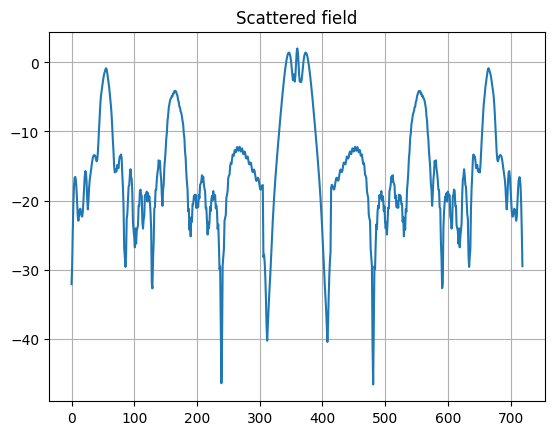

In [7]:
paths = scene.compute_paths(max_depth=1,
                            method="exhaustive",
                            num_samples=1e6,
                            los = True,
                            reflection = True,
                            diffraction = True,
                            vertex_diffraction = False,
                            double_diffraction = False,)

paths.normalize_delays = False
a, tau = paths.cir()
#a.shape   # [batch_size, num_rx, num_rx_ant, num_tx, num_tx_ant, max_num_paths, num_time_steps]

nans_bool = tf.math.is_nan(tf.math.real(a)) 
a = tf.where(nans_bool, tf.zeros_like(a), a)

path_amplitudes = a[0,:,0,0,0,:,0]
tmp1 = np.sum(path_amplitudes, axis=1) + field_los_full2
receiver_amplitudes_ = np.abs(tmp1) / lamda

plt.plot(20*np.log10(coef*receiver_amplitudes_))
plt.title('Scattered field')
plt.grid()

/home/matte/Documenti/Materiale per tesi/sionna-RT-reflectivity-main/sionna/rt/double_diffraction.py:2963: RuntimeWarning: divide by zero encountered in divide
  spreading_factor = np.sqrt(r1) / (np.sqrt(l * r2) * np.sqrt(r1 + l + r2))


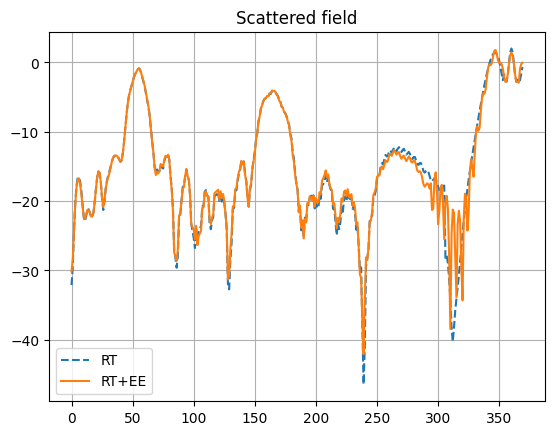

In [8]:
paths = scene.compute_paths(max_depth=1,
                            method="exhaustive",
                            num_samples=1e6,
                            los = True,
                            reflection = True,
                            diffraction = True,
                            vertex_diffraction = False,
                            double_diffraction = True,)

paths.normalize_delays = False

a, tau = paths.cir()
#a.shape   # [batch_size, num_rx, num_rx_ant, num_tx, num_tx_ant, max_num_paths, num_time_steps]

nans_bool = tf.math.is_nan(tf.math.real(a)) 
a = tf.where(nans_bool, tf.zeros_like(a), a)

path_amplitudes = a[0,:,0,0,0,:,0]
tmp1 = np.sum(path_amplitudes, axis=1) + field_los_full2
receiver_amplitudes = np.abs(tmp1) / lamda

plt.plot(20*np.log10(coef*receiver_amplitudes_[:num_points//2 + 10]), label='RT', linestyle='--')
plt.plot(20*np.log10(coef*receiver_amplitudes[:num_points//2 + 10]), label='RT+EE')
plt.title('Scattered field')
plt.grid()
plt.legend()

In [9]:
# Analytical curve (plane-wave incidence)
from sionna.rt.analytical_equations import cylinder_te_inc_scat_total, cylinder_tm_inc_scat_total
	
if pol == 'HH':
	u_inc, an_scattering, an_total = cylinder_te_inc_scat_total(theta_arr, cylinder_radius, circle_radius, 2*np.pi / lamda, terms=512)
elif pol == 'VV':
	u_inc, an_scattering, an_total = cylinder_tm_inc_scat_total(theta_arr, cylinder_radius, circle_radius, 2*np.pi / lamda, terms=512)

In [10]:
# los_line_idx
back_idxs = np.concatenate((np.arange(los_line_idx[0]), np.arange(los_line_idx[1], num_points)))
forw_idxs = np.arange(los_line_idx[0], los_line_idx[1])

def rmse(x, y, idxs):
	return np.sqrt(np.mean((x[idxs]-y[idxs])**2))


rmse_ee = rmse(20*np.log10(np.abs(an_scattering)), 20*np.log10(coef*receiver_amplitudes), back_idxs)
rmse_ee

np.float64(8.173658065705057)

Text(0, 0.5, '|E_sc| (dB)')

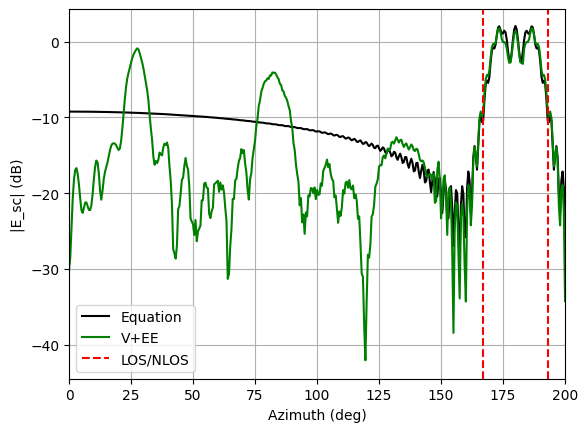

In [11]:
plt.plot(57.3*theta_arr, 20*np.log10(np.abs(an_scattering)), 'k', label='Equation')
plt.plot(57.3*theta_arr, 20*np.log10(coef*receiver_amplitudes), 'g', label='V+EE')
plt.axvline(x=57.3*theta_arr[los_line_idx[0]], color='r', linestyle='--', label='LOS/NLOS')
plt.axvline(x=57.3*theta_arr[los_line_idx[1]], color='r', linestyle='--')
plt.grid()
plt.xlim(0, 200)
plt.legend()
plt.xlabel("Azimuth (deg)")
plt.ylabel("|E_sc| (dB)")

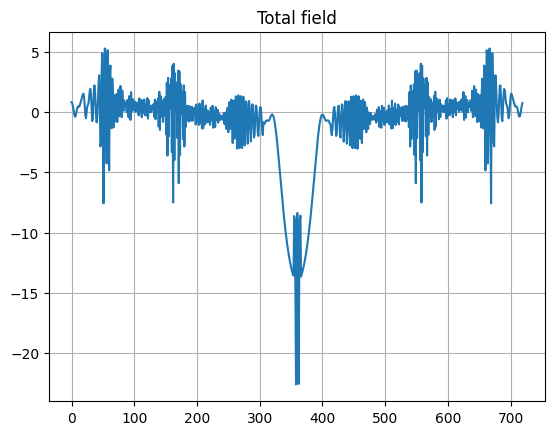

In [12]:
# COSA CAMBIA QUI RISPETTO A PRIMA ?????????????????

paths = scene.compute_paths(max_depth=1,
                            method="exhaustive",
                            num_samples=1e6,
                            los = True,
                            reflection = True,
                            diffraction = True,
                            vertex_diffraction = False,
                            double_diffraction = False,)

a, tau = paths.cir()
#a.shape   # [batch_size, num_rx, num_rx_ant, num_tx, num_tx_ant, max_num_paths, num_time_steps]

nans_bool = tf.math.is_nan(tf.math.real(a)) 
a = tf.where(nans_bool, tf.zeros_like(a), a)

path_amplitudes = a[0,:,0,0,0,:,0]
tmp1 = np.sum(path_amplitudes, axis=1)
receiver_amplitudes_ = np.abs(tmp1) / lamda

plt.plot(20*np.log10(coef*receiver_amplitudes_))
plt.title('Total field')
plt.grid()

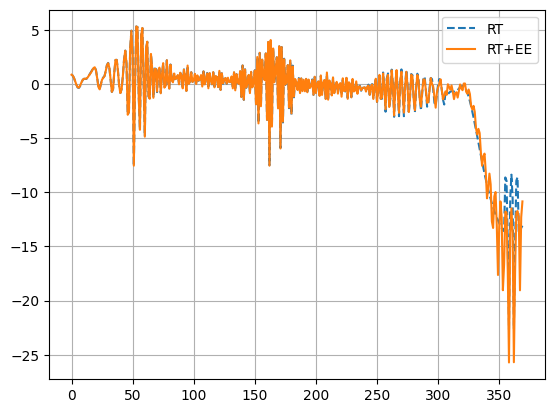

In [13]:
paths = scene.compute_paths(max_depth=1,
                            method="exhaustive",
                            num_samples=1e6,
                            los = True,
                            reflection = True,
                            diffraction = True,
                            vertex_diffraction = False,
                            double_diffraction = True,)

a, tau = paths.cir()
#a.shape   # [batch_size, num_rx, num_rx_ant, num_tx, num_tx_ant, max_num_paths, num_time_steps]

nans_bool = tf.math.is_nan(tf.math.real(a)) 
a = tf.where(nans_bool, tf.zeros_like(a), a)

path_amplitudes = a[0,:,0,0,0,:,0]
tmp1 = np.sum(path_amplitudes, axis=1)
receiver_amplitudes = np.abs(tmp1) / lamda

plt.plot(20*np.log10(coef*receiver_amplitudes_[:num_points//2+10]), label='RT', linestyle='--')
plt.plot(20*np.log10(coef*receiver_amplitudes[:num_points//2+10]), label='RT+EE')
# plt.title('Total field')
plt.grid()
plt.legend()

In [14]:
# Errore quadratico medio

rmse_ee = rmse(20*np.log10(np.abs(an_total)), 20*np.log10(coef*receiver_amplitudes), forw_idxs)
rmse_ee

np.float64(1.0645326901729504)

Text(0, 0.5, '|E_tot| (dB)')

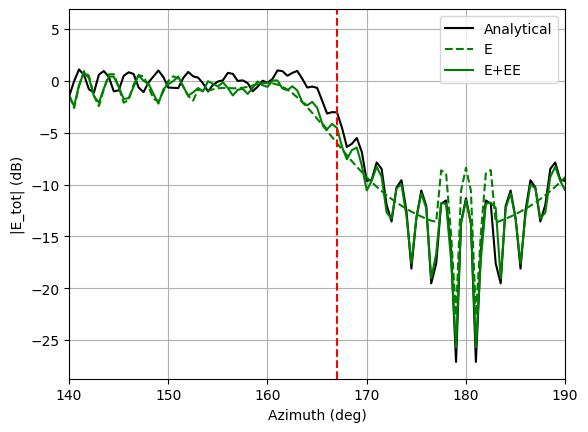

In [15]:
plt.plot(57.3*theta_arr, 20*np.log10(np.abs(an_total)), 'k', label='Analytical')
plt.plot(57.3*theta_arr, 20*np.log10(coef*receiver_amplitudes_), 'g--', label='E')
plt.plot(57.3*theta_arr, 20*np.log10(coef*receiver_amplitudes), 'g', label='E+EE')
	
# plt.plot(20*np.log10(coef*receiver_amplitudes_no[:num_points//2+1]), label='RT')
# plt.plot(20*np.log10(coef*receiver_amplitudes[:num_points//2+1]), label='RT+DD')
plt.axvline(x=theta_arr[los_line_idx[0]]*57.3, color='r', linestyle='--')
plt.grid()
plt.xlim(140, 190)
plt.legend()
plt.xlabel("Azimuth (deg)")
plt.ylabel("|E_tot| (dB)")

In [16]:
los_line_idx

(np.int64(334), np.int64(386))